In [175]:
import os
import sys
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

from pathlib import Path
import cv2
import pickle
import numpy as np
import matplotlib.pyplot as plt
import math
import json
from datetime import date
plt.rcParams["figure.figsize"] = (24,18)
from ultralytics import YOLO
from utils import *

In [2]:
model_path = os.path.join(os.path.dirname(os.getcwd()), 'models')
model = YOLO(os.path.join(model_path, "yolov8n.pt"))

In [3]:
data_path = os.path.join(os.path.dirname(os.getcwd()), 'data')
vid_name =  'real_test'

True


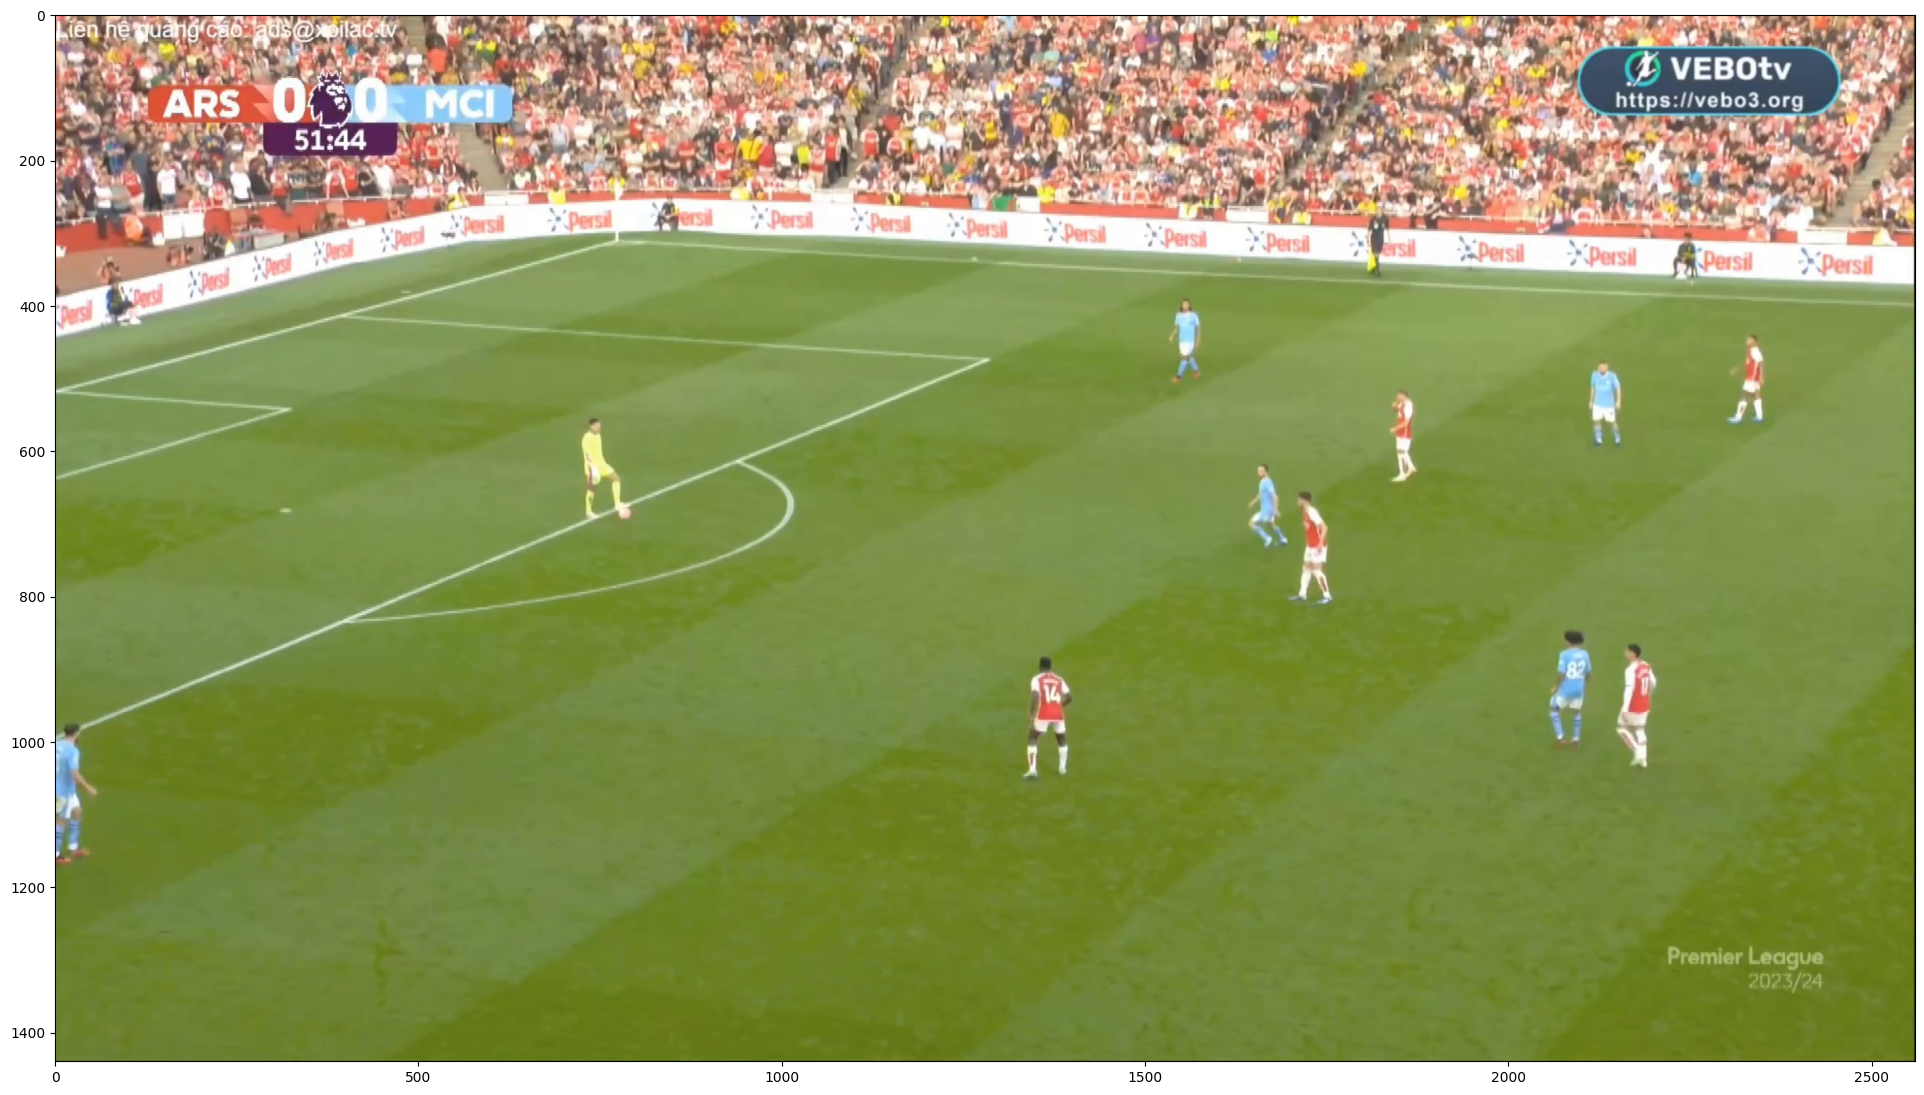

In [70]:
images_path = os.path.join(data_path, 'images' + '/' + vid_name)
print(os.path.exists(images_path))
images_path
image_path = os.path.join(images_path, os.listdir(images_path)[2])

rgb_image = cv2.imread(image_path, cv2.COLOR_BGR2RGB)

plt.figure()
plt.imshow(rgb_image[:,:,::-1])

[   0  296 2560 1144]


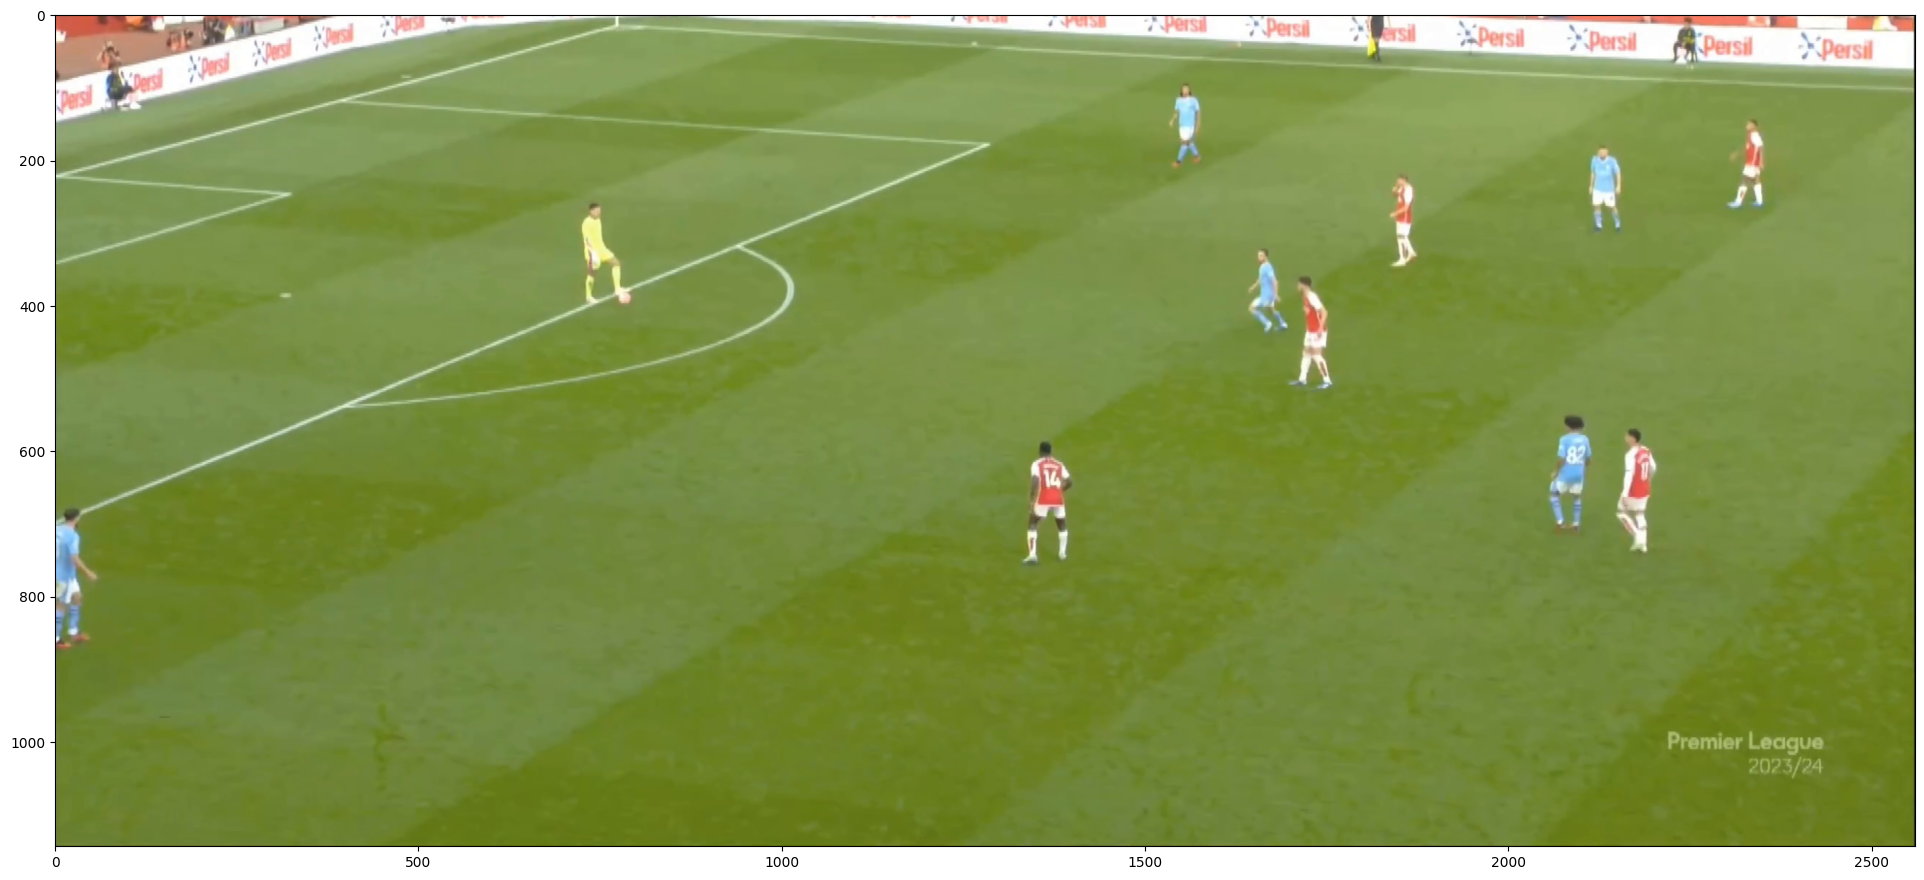

In [71]:
hsv_image = cv2.cvtColor(rgb_image, cv2.COLOR_BGR2HSV)
lower_green = np.array([35, 20, 50])
upper_green = np.array([90, 255, 255])

mask_green = cv2.inRange(hsv_image, lower_green, upper_green)
result = cv2.bitwise_and(hsv_image, hsv_image, mask=mask_green)
temp = cv2.cvtColor(result, cv2.COLOR_HSV2RGB)
h, w, _ = result.shape
_, green, _ = cv2.split(temp)

#ret, thresh = cv2.threshold(temp, 150, 255, cv2.THRESH_BINARY)

contours, hierarchy = cv2.findContours(image=green, mode=cv2.RETR_EXTERNAL,
                                      method=cv2.CHAIN_APPROX_NONE)

contours = max(contours, key=cv2.contourArea)
rect = np.int16(cv2.boundingRect(contours))
min_x, min_y, w, h = rect
max_x, max_y = [min_x + w, min_y + h]
print(rect)
#cv2.polylines(img=temp, pts=[contours], isClosed=False, color=(255, 0, 0), thickness=5)
cv2.rectangle(temp, (min_x, min_y), (max_x, max_y),color=(255, 0, 0), thickness=5)

plt.imshow(temp[min_y:max_y, min_x:max_x])

# Crop the image
result = cv2.resize(result[min_y:max_y, min_x:max_x], (w, h))
rgb_image = cv2.resize(rgb_image[min_y:max_y, min_x:max_x], (w, h))
plt.imshow(rgb_image[:,:,::-1])

In [126]:
first_batch = os.listdir(images_path)[0:1]
image_path = [os.path.join(images_path, x) for x in first_batch]
image_path

['/home/huy-ng/Project/Football-analysis/data/images/real_test/000000000130.png']


0: 288x640 17 persons, 1 ball, 9.1ms
Speed: 8.0ms preprocess, 9.1ms inference, 1.2ms postprocess per image at shape (1, 3, 288, 640)


True


/home/huy-ng/Project/Football-analysis/.venv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)

0: 320x640 10 persons, 1 ball, 7.0ms
Speed: 1.6ms preprocess, 7.0ms inference, 0.9ms postprocess per image at shape (1, 3, 320, 640)
/home/huy-ng/Project/Football-analysis/.venv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)

0: 288x640 11 persons, 7.2ms
Speed: 1.4ms preprocess, 7.2ms inference, 0.8ms postprocess per image at shape (1, 3, 288, 640)
/home/huy-ng/Project/Football-analysis/.venv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The defau

[200.11566947764058, 45.395476944938316, 65.10443330638539, 123.1244388932904, 57.04337015943905, 118.54438055095615, 154.70261305675902, 11.409866974919845, 200.11566947764058]


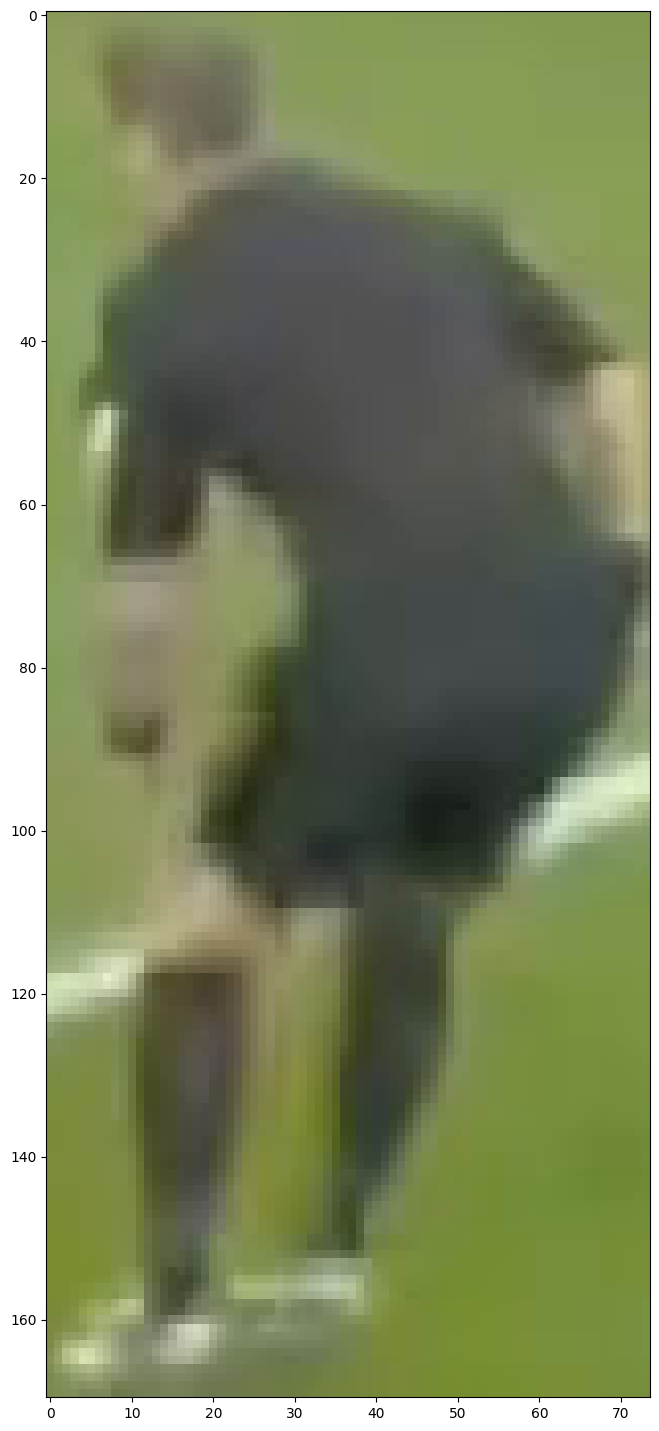

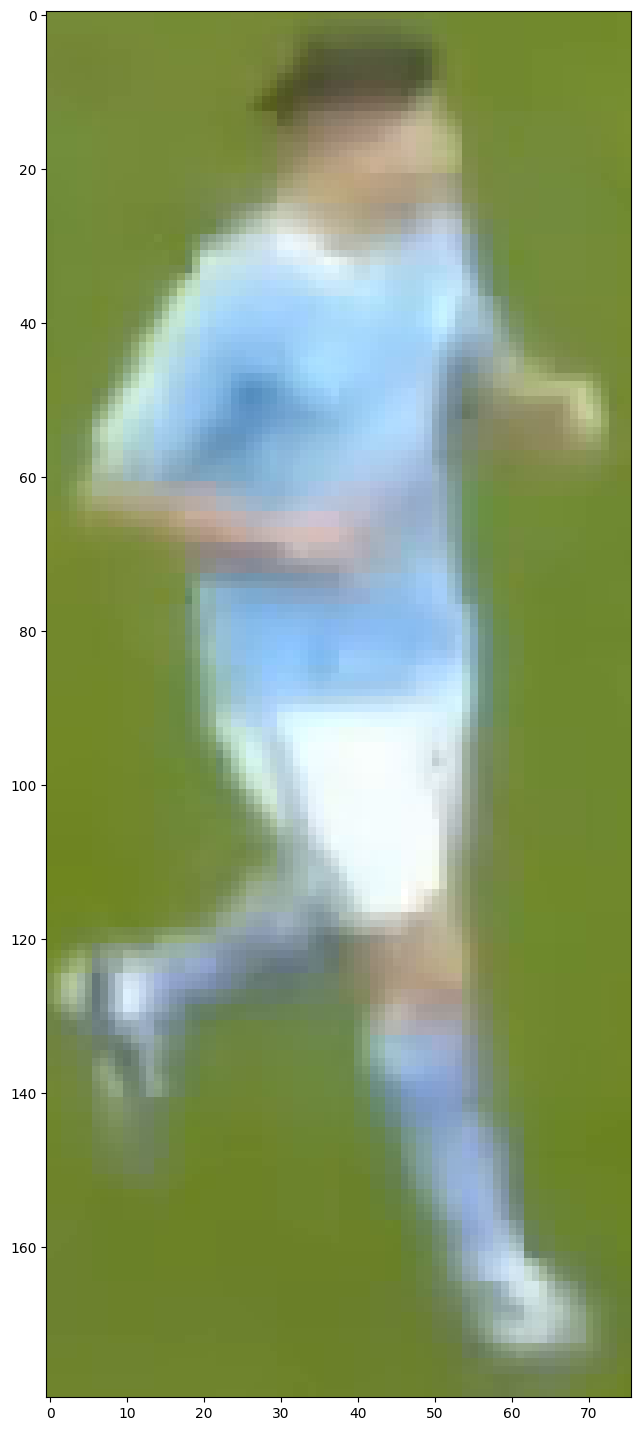

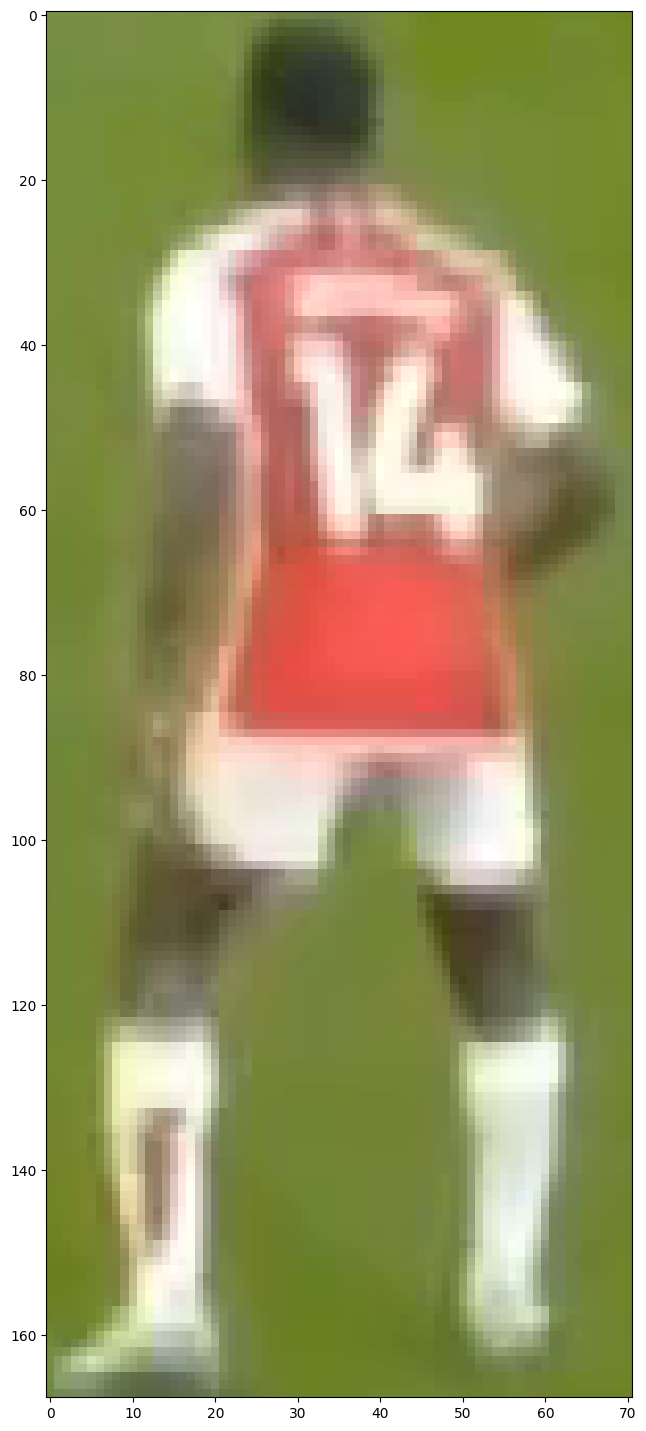

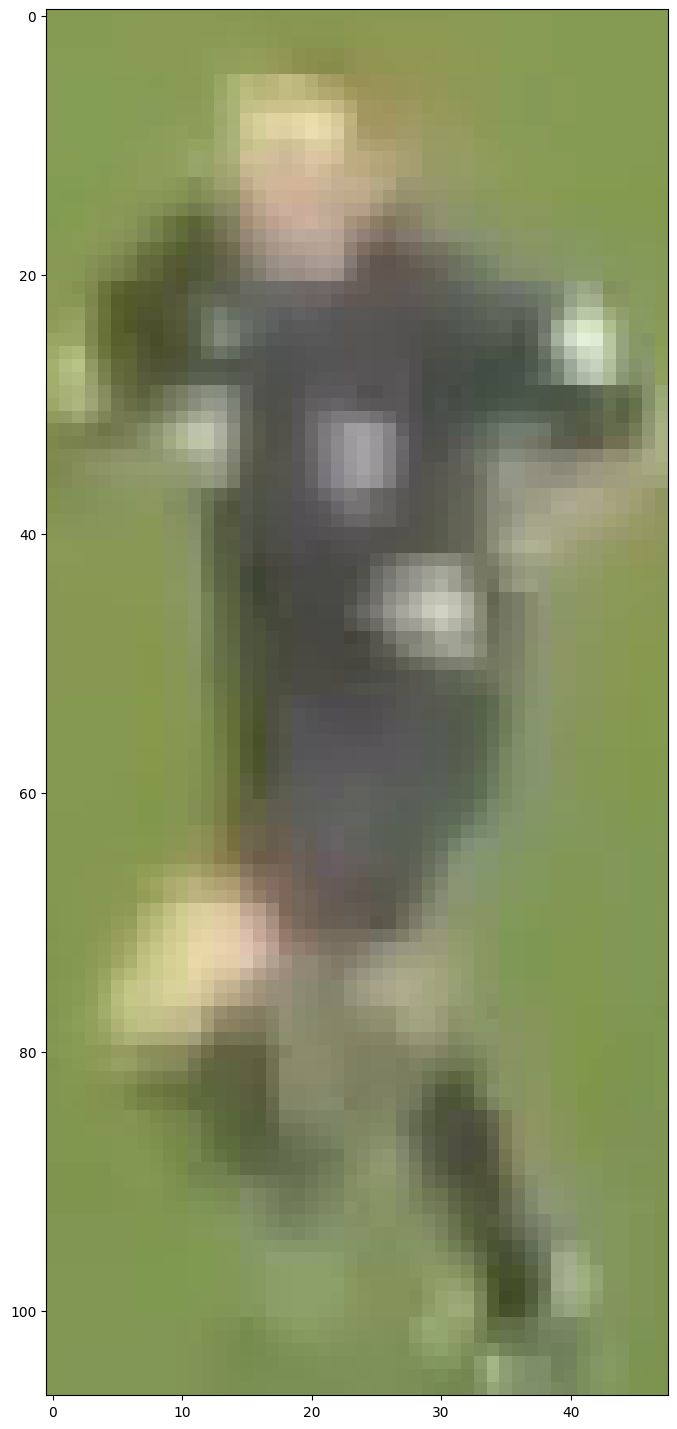

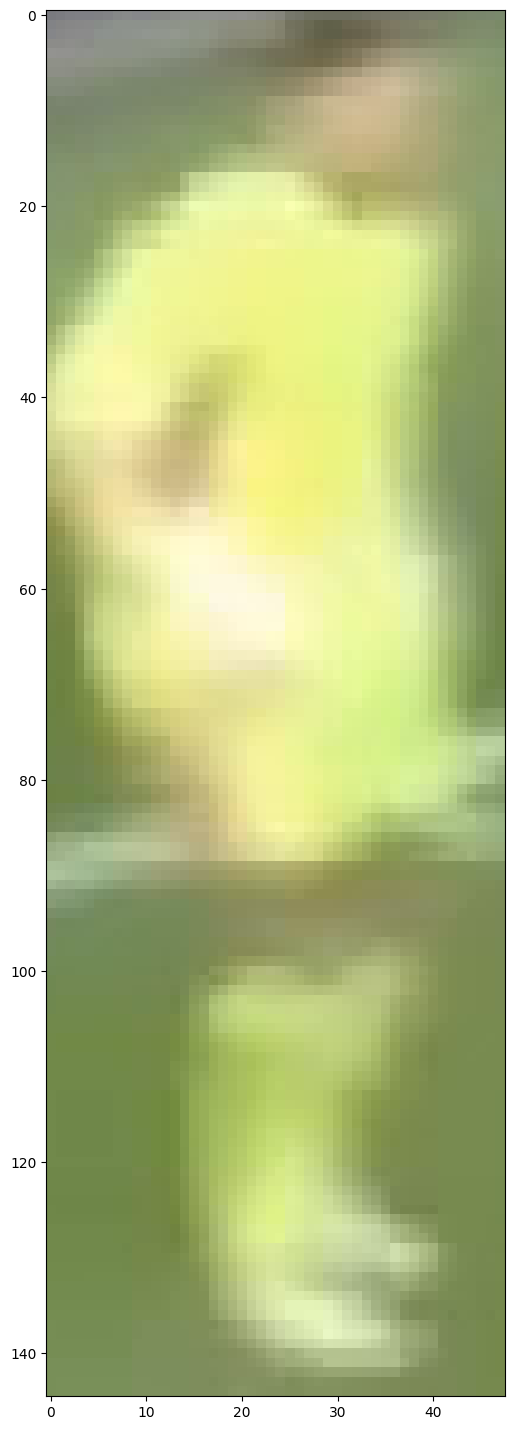

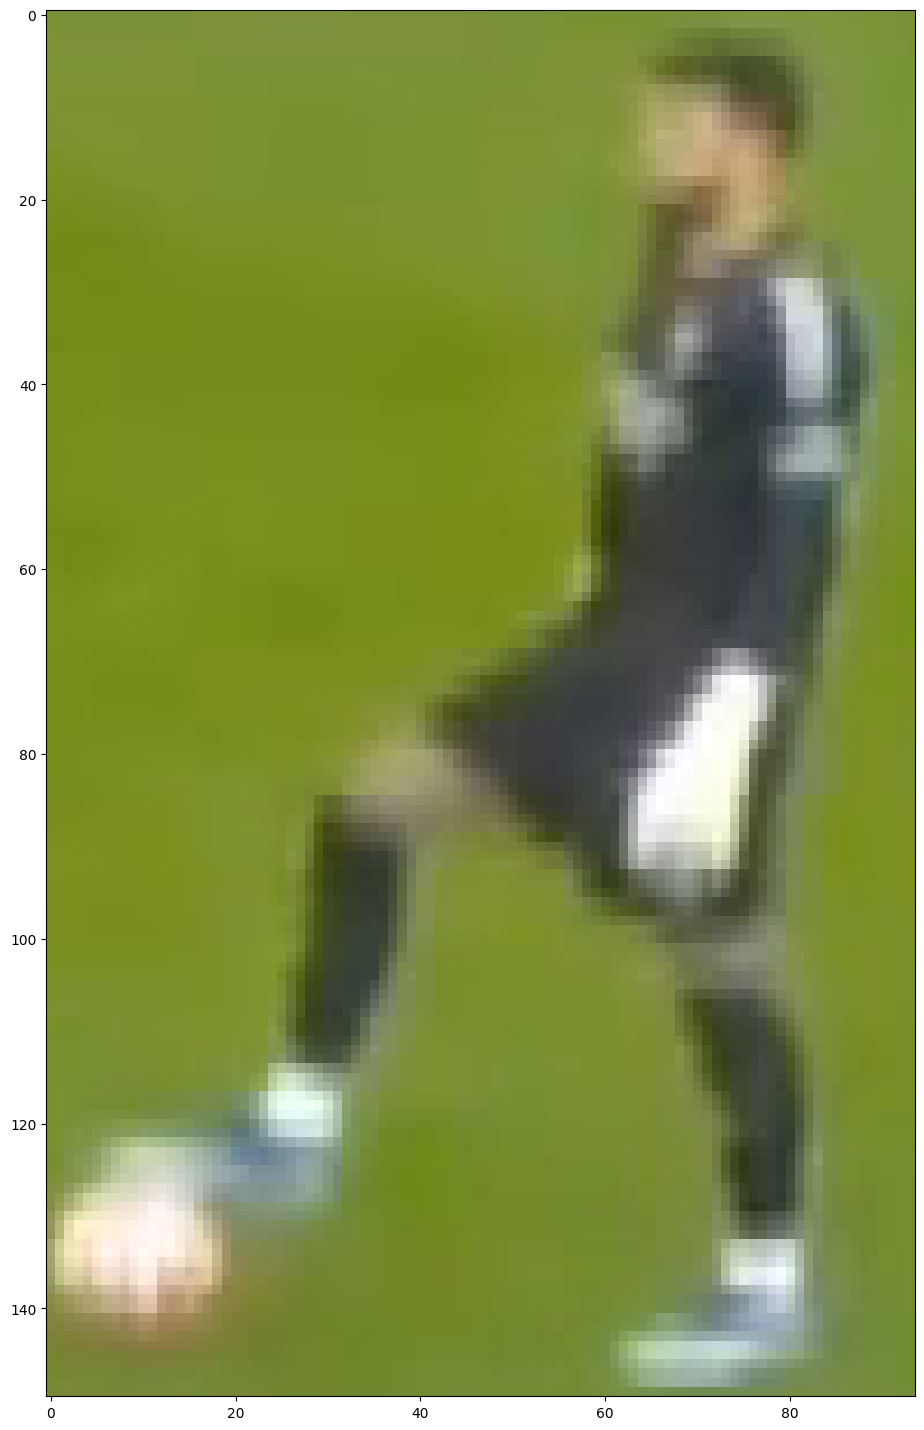

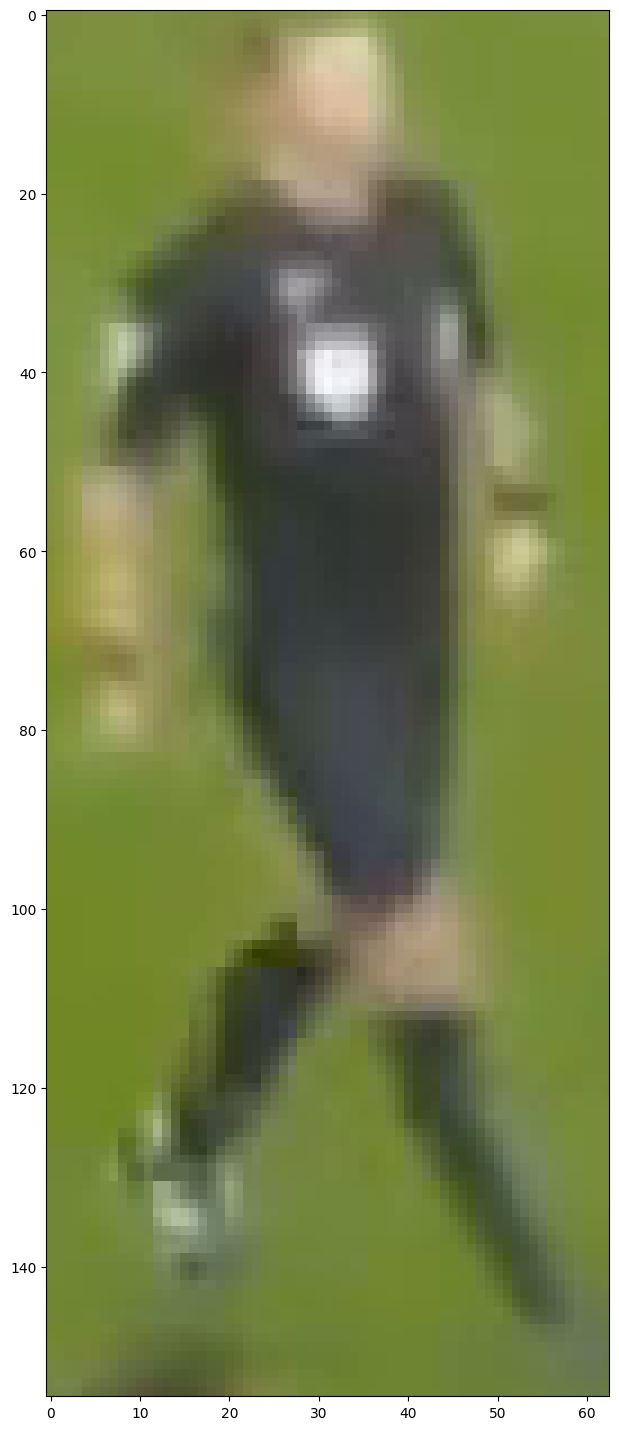

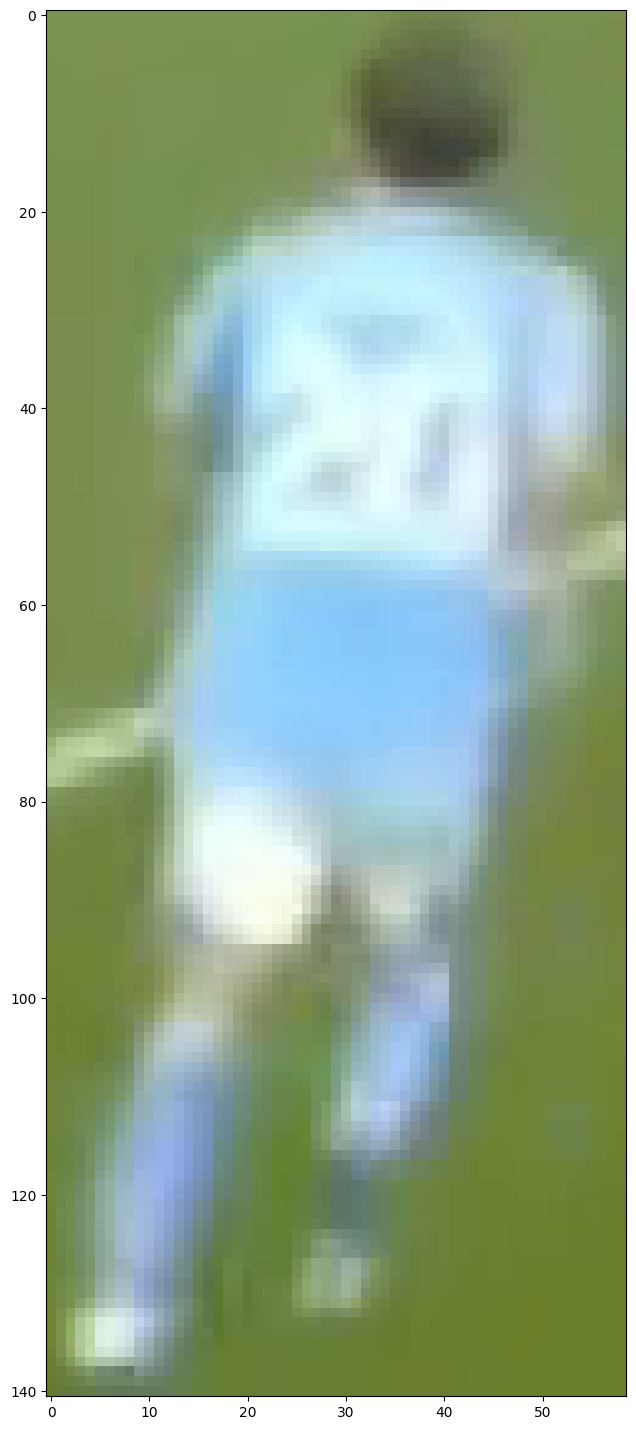

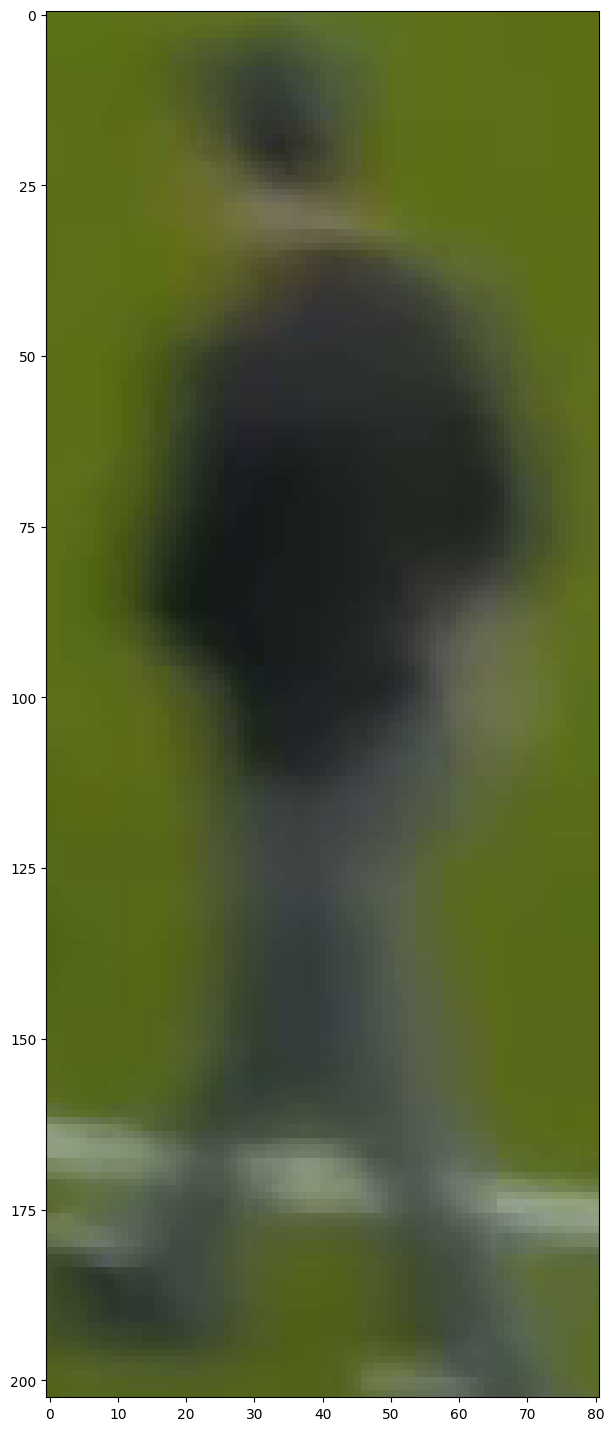

In [192]:
from sklearn.cluster import KMeans
from collections import Counter

images_path = os.path.join(data_path, 'images' + '/' + vid_name)
print(os.path.exists(images_path))
first_batch = os.listdir(images_path)[0:9]
image_batch = [os.path.join(images_path, x) for x in first_batch]        # Get several images to test

team_1_color = []
team_2_color = []
misc_color   = []
diff_misc    = []
frame_num = 0


for image_ad in image_batch:
    rgb_image = cv2.imread(image_ad, cv2.COLOR_BGR2RGB)

    ## pitch seg
    hsv_image = cv2.cvtColor(rgb_image, cv2.COLOR_BGR2HSV)
    lower_green = np.array([35, 20, 50])
    upper_green = np.array([90, 255, 255])

    mask_green = cv2.inRange(hsv_image, lower_green, upper_green)
    result = cv2.bitwise_and(hsv_image, hsv_image, mask=mask_green)
    temp = cv2.cvtColor(result, cv2.COLOR_HSV2RGB)
    h, w, _ = result.shape
    _, green, _ = cv2.split(temp)

    #ret, thresh = cv2.threshold(temp, 150, 255, cv2.THRESH_BINARY)

    contours, hierarchy = cv2.findContours(image=green, mode=cv2.RETR_EXTERNAL,
                                      method=cv2.CHAIN_APPROX_NONE)

    contours = max(contours, key=cv2.contourArea)
    rect = np.int16(cv2.boundingRect(contours))
    min_x, min_y, w, h = rect
    max_x, max_y = [min_x + w, min_y + h]
    #cv2.polylines(img=temp, pts=[contours], isClosed=False, color=(255, 0, 0), thickness=5)
    cv2.rectangle(temp, (min_x, min_y), (max_x, max_y),color=(255, 0, 0), thickness=5)

    # Crop the image
    result = cv2.resize(result[min_y:max_y, min_x:max_x], (w, h))
    rgb_image = cv2.resize(rgb_image[min_y:max_y, min_x:max_x], (w, h))
    #plt.figure()
    #plt.imshow(rgb_image[:,:,::-1])
    ## run the model

    results = model.predict(rgb_image)
    boxes = results[0].boxes
    #print(boxes.cls)
    # Compute hue of grass
    grass_average = rgb_image[:,:,::-1].mean(axis=0).mean(axis=0)
    # Assignment 
    assignment=[]
    crop_img_list = []
    
    for box in boxes:
        if box.cls[0].item() == 0:   # if the person then continue to compute hue
            crop = box.xyxy
            (startX, startY, endX, endY) = np.concatenate(crop.cpu().detach().int().tolist())
            cropped = rgb_image[startY:endY,startX:endX]
            test_crop = cropped[:,:,::-1].copy()
            crop_img_list.append(test_crop)
            result = []
            for row_idx in range(cropped.shape[0]):
                for col_idx in range(cropped.shape[1]):        
                    current_color = test_crop[row_idx][col_idx]
                    if sum(abs(current_color - grass_average)) > 60:
                        result.append(current_color)
            final_color = np.mean(result,axis = 0)
            assignment.append(final_color)

    kmeans = KMeans(n_clusters=3)
    s=kmeans.fit(assignment)
    labels=kmeans.labels_
    teams = Counter(labels).most_common(3)
    #print(teams)
    team_1 = np.where(labels == teams[0][0])[0]
    team_2 = np.where(labels == teams[1][0])[0]
    misc   = np.where(labels == teams[2][0])[0]

    # labels = list(map(lambda x: x if x != teams[0][0] else 'Team 1', labels))
    # labels = list(map(lambda x: x if x != teams[1][0] else 'Team 2', labels))
    # labels = list(map(lambda x: x if x != teams[2][0] else 'Misc', labels))
    # team_1_mod = np.where(np.array(labels) == 'Misc')[0]
    # tester_pic = crop_img_list[team_1_mod[0]] 
    # plt.figure()
    # plt.imshow(tester_pic)
    # print(diff_misc_color)

    if frame_num == 0:
        team_1_color = np.mean([assignment[i] for i in team_1],axis =0)
        team_2_color = np.mean([assignment[i] for i in team_2],axis =0)
        misc_color   = np.mean([assignment[i] for i in misc],axis = 0)
        labels = list(map(lambda x: x if x != teams[0][0] else 'Team 1', labels))
        labels = list(map(lambda x: x if x != teams[1][0] else 'Team 2', labels))
        labels = list(map(lambda x: x if x != teams[2][0] else 'Misc', labels))
        team_1_mod = np.where(np.array(labels) == 'Misc')[0]
        tester_pic = crop_img_list[team_1_mod[0]] 
        plt.figure()
        plt.imshow(tester_pic)
        diff_misc.append(diff_misc_color)        
        
    
    if frame_num > 0:
        current_team_1_color = np.mean([assignment[i] for i in team_1],axis =0)
        current_team_2_color = np.mean([assignment[i] for i in team_2],axis =0)
        current_misc_color = np.mean([assignment[i] for i in misc],axis =0)
        diff_color_team_1_1 = np.linalg.norm(team_1_color-current_team_1_color)
        diff_color_team_1_2 = np.linalg.norm(misc_color-current_team_2_color)
        diff_misc_color = np.linalg.norm(team_1_color-current_misc_color)
        labels = list(map(lambda x: x if x != teams[2][0] else 'Misc', labels)) # Comment this
        if  diff_color_team_1_1 < diff_color_team_1_2:
            labels = list(map(lambda x: x if x != teams[0][0] else 'Team 1', labels))
            labels = list(map(lambda x: x if x != teams[1][0] else 'Team 2', labels))
        else: 
            labels = list(map(lambda x: x if x != teams[1][0] else 'Team 1', labels))
            labels = list(map(lambda x: x if x != teams[0][0] else 'Team 2', labels))
        #print(labels)
        team_1_mod = np.where(np.array(labels) == 'Misc')[0]
        tester_pic = crop_img_list[team_1_mod[0]] 
        plt.figure()
        plt.imshow(tester_pic)
        diff_misc.append(diff_misc_color)
        
    frame_num +=1
    
    
print(diff_misc)
    #plt.figure()
    #plt.imshow(misc_pic)

In [168]:
labels = np.array(['Team 2', 'Team 2', 'Misc', 'Team 2', 'Misc', 'Team 1', 'Team 1', 'Team 1', 'Team 1', 'Misc'])
team_1_mod = np.where(labels == 'Team 1')
print(team_1_mod)

(array([5, 6, 7, 8]),)


In [ ]:
results = model.predict(rgb_image)
boxes = results[0].boxes
print(boxes.cls)
# Compute hue of grass
grass_average = rgb_image[:,:,::-1].mean(axis=0).mean(axis=0)
# Assignment 
assignment=[]
for crop in boxes.xyxy:
    (startX, startY, endX, endY) = coord = crop.cpu().detach().int().tolist()
    cropped = rgb_image[startY:endY,startX:endX]
    test_crop = cropped[:,:,::-1].copy()
    result = []
    for row_idx in range(cropped.shape[0]):
        for col_idx in range(cropped.shape[1]):        
            current_color = test_crop[row_idx][col_idx]
            if sum(abs(current_color - grass_average)) > 60:
                  result.append(current_color)
    final_color = np.mean(result,axis = 0)
    assignment.append(final_color)

kmeans = KMeans(n_clusters=3)
s=kmeans.fit(assignment)
labels=kmeans.labels_
print(labels)
teams = Counter(labels).most_common(3)
print(teams)
team_1 = np.where(labels == teams[0][0])[0]
team_2 = np.where(labels == teams[1][0])[0]
misc   = np.where(labels == teams[2][0])[0]


0: 288x640 17 persons, 1 ball, 29.0ms
Speed: 1.3ms preprocess, 29.0ms inference, 0.5ms postprocess per image at shape (1, 3, 288, 640)


True
[   0  334 2560 1106]
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])


/home/huy-ng/Project/Football-analysis/.venv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


[1 2 2 0 2 0 0 0 0 2 0 2 0 2 0 2 0 2]
[(0, 9), (2, 8), (1, 1)]


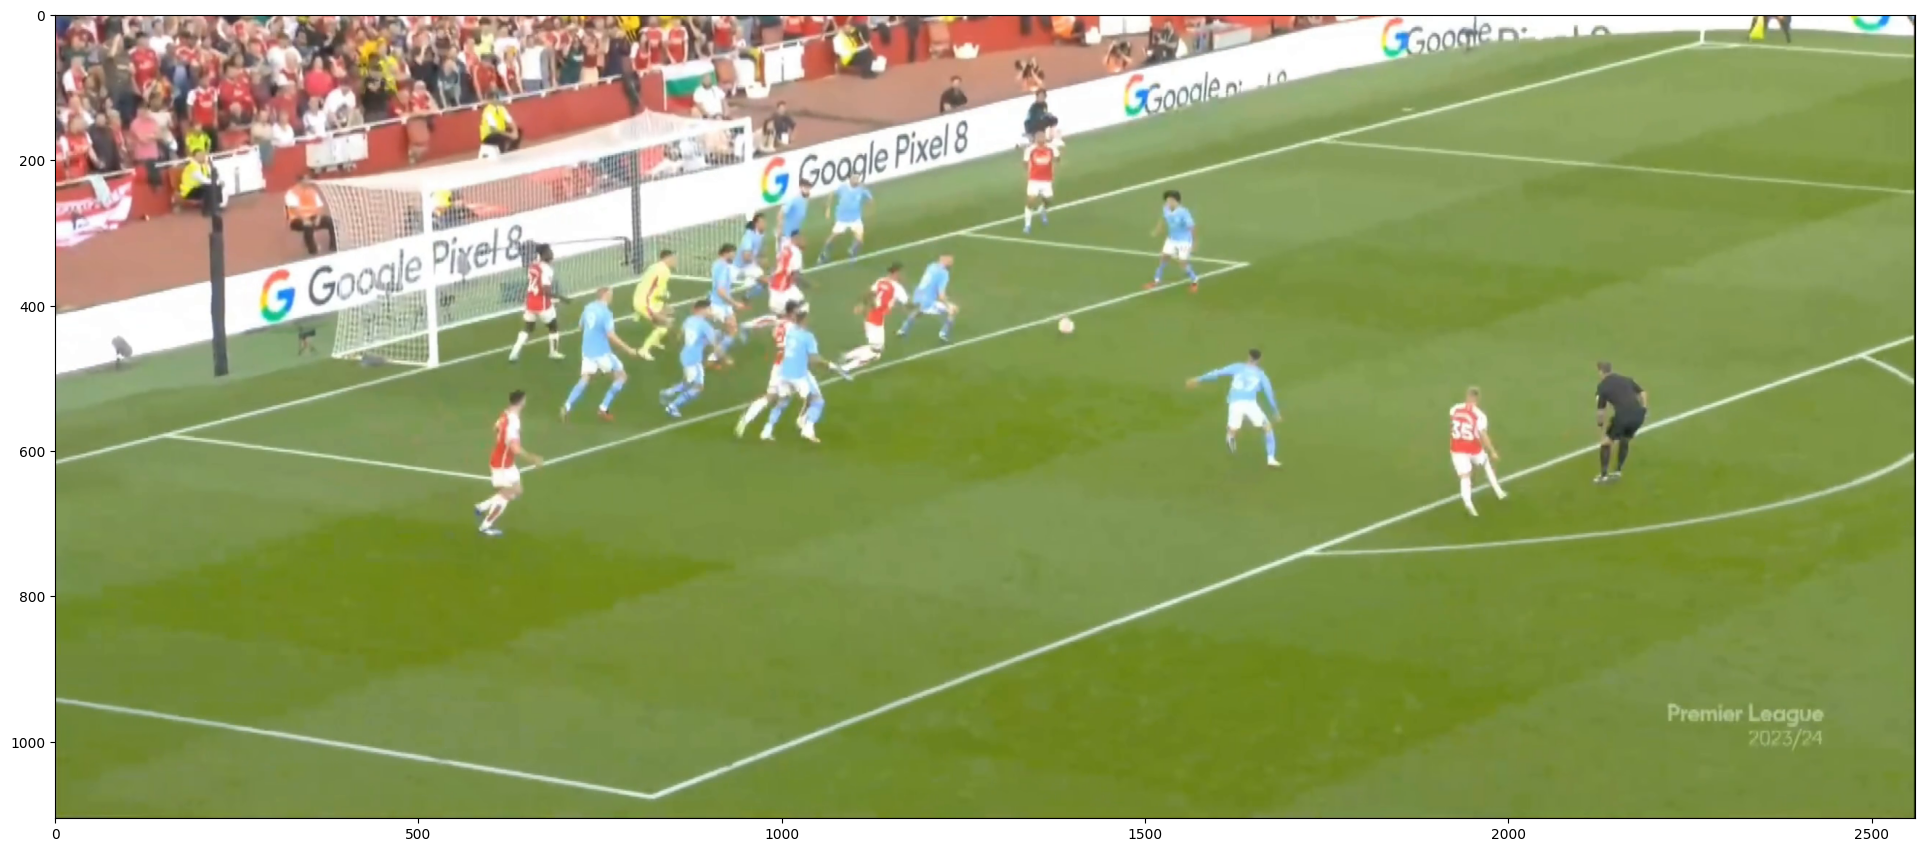

In [161]:
from sklearn.cluster import KMeans
from collections import Counter

# Import images
team_1_color = []
team_2_color = []
misc_color   = []

images_path = os.path.join(data_path, 'images' + '/' + vid_name)
print(os.path.exists(images_path))
image_path = os.path.join(images_path, os.listdir(images_path)[0])
rgb_image = cv2.imread(image_path, cv2.COLOR_BGR2RGB)

## pitch seg
hsv_image = cv2.cvtColor(rgb_image, cv2.COLOR_BGR2HSV)
lower_green = np.array([35, 20, 50])
upper_green = np.array([90, 255, 255])

mask_green = cv2.inRange(hsv_image, lower_green, upper_green)
result = cv2.bitwise_and(hsv_image, hsv_image, mask=mask_green)
temp = cv2.cvtColor(result, cv2.COLOR_HSV2RGB)
h, w, _ = result.shape
_, green, _ = cv2.split(temp)

#ret, thresh = cv2.threshold(temp, 150, 255, cv2.THRESH_BINARY)

contours, hierarchy = cv2.findContours(image=green, mode=cv2.RETR_EXTERNAL,
                                      method=cv2.CHAIN_APPROX_NONE)

contours = max(contours, key=cv2.contourArea)
rect = np.int16(cv2.boundingRect(contours))
min_x, min_y, w, h = rect
max_x, max_y = [min_x + w, min_y + h]
print(rect)
#cv2.polylines(img=temp, pts=[contours], isClosed=False, color=(255, 0, 0), thickness=5)
cv2.rectangle(temp, (min_x, min_y), (max_x, max_y),color=(255, 0, 0), thickness=5)

# Crop the image
result = cv2.resize(result[min_y:max_y, min_x:max_x], (w, h))
rgb_image = cv2.resize(rgb_image[min_y:max_y, min_x:max_x], (w, h))
plt.figure()
plt.imshow(rgb_image[:,:,::-1])
## run the model

results = model.predict(rgb_image)
boxes = results[0].boxes
print(boxes.cls)
# Compute hue of grass
grass_average = rgb_image[:,:,::-1].mean(axis=0).mean(axis=0)
# Assignment 
assignment=[]
for crop in boxes.xyxy:
    (startX, startY, endX, endY) = coord = crop.cpu().detach().int().tolist()
    cropped = rgb_image[startY:endY,startX:endX]
    test_crop = cropped[:,:,::-1].copy()
    result = []
    for row_idx in range(cropped.shape[0]):
        for col_idx in range(cropped.shape[1]):        
            current_color = test_crop[row_idx][col_idx]
            if sum(abs(current_color - grass_average)) > 60:
                  result.append(current_color)
    final_color = np.mean(result,axis = 0)
    assignment.append(final_color)

kmeans = KMeans(n_clusters=3)
s=kmeans.fit(assignment)
labels=kmeans.labels_
print(labels)
teams = Counter(labels).most_common(3)
print(teams)
team_1 = np.where(labels == teams[0][0])[0]
team_2 = np.where(labels == teams[1][0])[0]
misc   = np.where(labels == teams[2][0])[0]
team_1_color = np.mean([assignment[i] for i in team_1],axis =0)
team_2_color = np.mean([assignment[i] for i in team_2],axis =0)
misc_color   = np.mean([assignment[i] for i in misc],axis = 0)


# Compare 

In [ ]:
def export_coco_dataset_from_prediction(data_path, folder_name, model_name="yolov8n.pt"):
    model_path = os.path.join(os.path.dirname(os.getcwd()), 'models')
    print(model_path)
    model = YOLO(os.path.join(model_path, model_name))

    images_path = os.path.join(data_path, 'images' + '/' + folder_name)

    dest_path = os.path.join(data_path, 'coco_datasets' + '/' + folder_name)
    if not os.path.exists(dest_path):
        os.mkdir(dest_path)

    dest_images_path = os.path.join(dest_path, 'images')
    if not os.path.exists(dest_images_path):
        os.mkdir(dest_images_path)

    dest_coco_path = os.path.join(dest_path, 'annotations')
    if not os.path.exists(dest_coco_path):
        os.mkdir(dest_coco_path)

    
    coco_dict ={}
    frame_id = 1
    obj_id = 1
    categories_dict = [{"id" : 1, "name" : "person", "supercategory" : None},
                    {"id" : 2, "name" : "ball", "supercategory" : None}]

    creation_date = date.today()
    year = creation_date.year
    coco_info = {
        'contributor': 'Khoa Nguyen, Huy Nguyen',
        'description': folder_name,
        'url': '',
        'version': 0,
        'date_created': str(creation_date),
        'year': year,
    }

    def crop_image(rgb_image):
        hsv_image = cv2.cvtColor(rgb_image, cv2.COLOR_BGR2HSV)
        lower_green = np.array([35, 20, 50])
        upper_green = np.array([90, 255, 255])

        mask_green = cv2.inRange(hsv_image, lower_green, upper_green)
        result = cv2.bitwise_and(hsv_image, hsv_image, mask=mask_green)
        temp = cv2.cvtColor(result, cv2.COLOR_HSV2RGB)
        h, w, _ = result.shape
        _, green, _ = cv2.split(temp)
        #ret, thresh = cv2.threshold(temp, 150, 255, cv2.THRESH_BINARY)
        contours, hierarchy = cv2.findContours(image=green, mode=cv2.RETR_EXTERNAL,
                                      method=cv2.CHAIN_APPROX_NONE)

        contours = max(contours, key=cv2.contourArea)
        rect = np.int0(cv2.boxPoints(cv2.minAreaRect(contours)))
        min_y, max_y = sorted(np.unique(rect[:, 1]))
        min_x, max_x = sorted(np.unique(rect[:, 0]))
        #cv2.polylines(img=temp, pts=[contours], isClosed=False, color=(255, 0, 0), thickness=5)
        cv2.polylines(img=temp, pts=[rect],
                             isClosed=True, color=(255, 0, 0), thickness=5)
        # Crop the image
        result = cv2.resize(result[min_y:max_y, min_x:max_x], (w, h))
        rgb_image = cv2.resize(rgb_image[min_y:max_y, min_x:max_x], (w, h))
        return rgb_image



    images = []
    annotations = []

    
    team_1_color = []
    team_2_color = []
    referee_color = []
    keeper_1_color = []
    keeper_2_color = []

    for image_name in os.listdir(images_path):
        frame = os.path.join(images_path, image_name)
        # Get image shape for COCO dataset:
        h, w, _ = cv2.imread(frame, cv2.IMREAD_UNCHANGED).shape

        # Set image metadata for COCO dataset:
        metadata = {"height" : h,
                    "width" : w,
                    "id" : frame_id,
                    "file_name": image_name}
        images.append(metadata)

        # Run YOLOv8 inference on the frame
        results = model(frame, classes=[0, 32])

        # Copy original image to coco dataset destination
        shutil.copy(frame, os.path.join(dest_images_path, image_name))


        # Modify prior -> to get assignment
        rgb_image = cv2.imread(image_path, cv2.COLOR_BGR2RGB)
        rgb_image = crop_image(rgb_image)
        grass_average = rgb_image[:,:,::-1].mean(axis=0).mean(axis=0)
        assignment=[]
        init_result = model.predict(rgb_image)
        init_boxes = init_result[0].boxes
        for crop in init_boxes.xyxy:
            (startX, startY, endX, endY) = crop.cpu().detach().int().tolist()
            cropped = rgb_image[startY:endY,startX:endX]
            test_crop = cropped[:,:,::-1].copy()
            list_color = []
            for row_idx in range(cropped.shape[0]):
                for col_idx in range(cropped.shape[1]):        
                    current_color = test_crop[row_idx][col_idx]
                    if sum(abs(current_color - grass_average)) > 60:
                        list_color.append(current_color)
                final_color = np.mean(list_color,axis = 0)
                assignment.append(final_color)
        kmeans = KMeans(n_clusters=3)
        s = kmeans.fit(assignment)
        labels = kmeans.labels_

        

        # Write information to coco dataset:
        boxes = results[0].boxes
        for box in boxes:
            (startX, startY, endX, endY) = box.xyxy.cpu().detach().int().tolist()[0]
            class_id = box.cls[0].item()
            bbox = {"id" : obj_id,
                    "image_id" : frame_id,
                    "category_id" : 1 if class_id == 0.0 else 2,
                    "segmentation" : [],
                    "bbox" : [startX, startY, endX-startX, endY-startY],
                        "area" : (endX-startX) * (endY-startY),
                    "iscrowd" : 0}
            
            annotations.append(bbox)
            obj_id += 1
        frame_id += 1



        


    coco_dict["info"] = coco_info
    coco_dict["license"] = {'name': folder_name,
                            'id': '',
                            'url': ''}
    coco_dict["categories"] = categories_dict
    coco_dict["images"] = images
    coco_dict["annotations"] = annotations

    with open(os.path.join(dest_coco_path, 'instances_default.json'), 'w') as coco:
        json.dump(coco_dict, coco)